In [1]:
import pandas as pd
import plotly.express as px
import pytz
from datetime import datetime

In [2]:
apps_df=pd.read_csv(r"C:\Users\ashis\OneDrive\Desktop\GooglePlayProject\Play Store Data.csv")

In [3]:
apps_df['Rating']=pd.to_numeric(apps_df['Rating'],errors='coerce')
apps_df=apps_df.dropna(subset=['Rating'])

In [4]:
apps_df['Reviews']=pd.to_numeric(apps_df['Reviews'],errors='coerce')
apps_df=apps_df.dropna(subset=['Reviews'])

In [5]:
apps_df['Installs']=apps_df['Installs'].str.replace('+','')
apps_df['Installs']=apps_df['Installs'].str.replace(',','')
apps_df=apps_df[apps_df['Installs']!='Free']
apps_df['Installs']=pd.to_numeric(apps_df['Installs'],errors='coerce')
apps_df=apps_df.dropna(subset=['Installs'])

In [6]:
apps_df=apps_df[apps_df['Size'].str.contains('M',na=False)]
apps_df['Size']=apps_df['Size'].str.replace('M','')
apps_df['Size']=pd.to_numeric(apps_df['Size'],errors='coerce')
apps_df=apps_df.dropna(subset=['Size'])

In [7]:
apps_df['Last Updated']=pd.to_datetime(apps_df['Last Updated'],errors='coerce')
apps_df=apps_df.dropna(subset=['Last Updated'])

In [8]:
apps_df=apps_df[
    (apps_df['Rating']>=4.2)&
    (~apps_df['App'].str.contains(r'\d',regex=True,na=False))&
    (apps_df['Category'].str.startswith(('T','P'),na=False))&
    (apps_df['Reviews']>1000)&
    (apps_df['Size']>=20)&
    (apps_df['Size']<=80)]

In [9]:
apps_df['Category']=apps_df['Category'].replace({
    'TRAVEL_AND_LOCAL':'Voyage et Local',
    'PRODUCTIVITY':'Productividad',
    'PHOTOGRAPHY':'写真'})

In [10]:
apps_df['Month']=apps_df['Last Updated'].dt.to_period('M').astype(str)

In [12]:
stacked_data=apps_df.groupby(['Month','Category'])['Installs'].sum().reset_index()

In [13]:
stacked_data['Growth']=stacked_data.groupby('Category')['Installs'].pct_change()

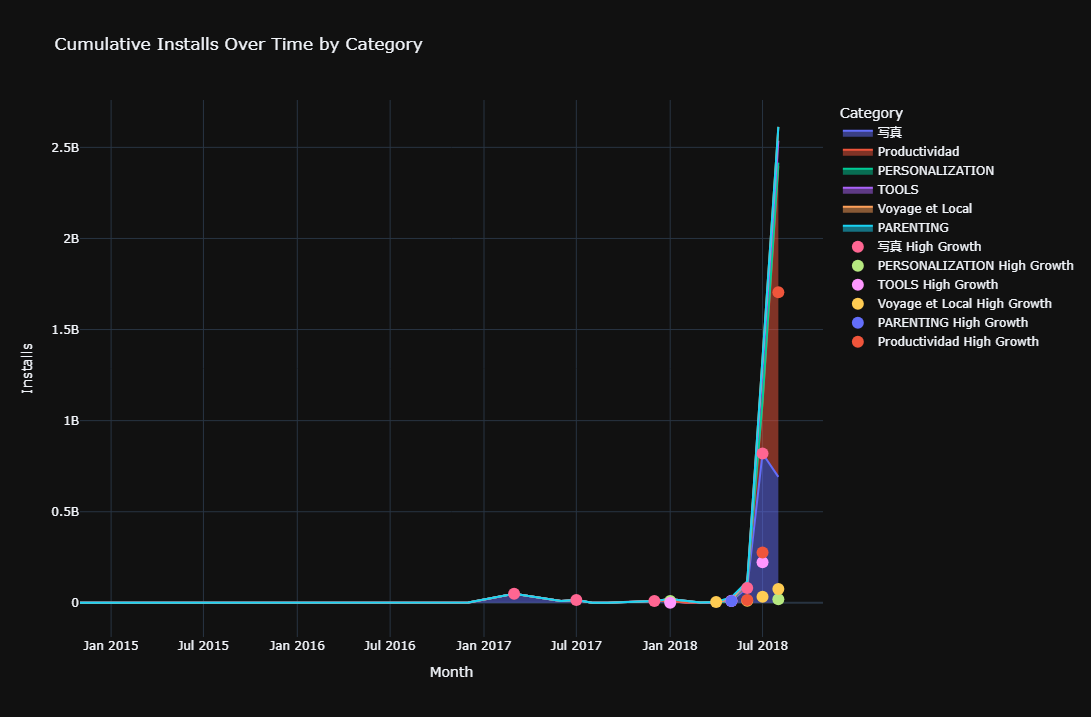

In [14]:
india=pytz.timezone('Asia/Kolkata')

current_time=datetime.now(india)

current_hour=current_time.hour

if 16<=current_hour<18:

    fig6=px.area(
        stacked_data,
        x='Month',
        y='Installs',
        color='Category',
        title='Cumulative Installs Over Time by Category'
    )

    growth_data=stacked_data[
        stacked_data['Growth']>0.25
    ]

    for category in growth_data['Category'].unique():

        category_data=growth_data[
            growth_data['Category']==category
        ]

        fig6.add_scatter(
            x=category_data['Month'],
            y=category_data['Installs'],
            mode='markers',
            marker=dict(size=12),
            name=f'{category} High Growth'
        )

    fig6.update_layout(
        template='plotly_dark',
        width=1200,
        height=700
    )

    fig6.show()

else:

    print("Graph available only between 4 PM IST and 6 PM IST")